# Projeto Final de Machine Learning 2
## Problema de Super-Resolução de Imagens
### Alunos: [Marcos Abílio]() e [Gabriel Vieira]()

## Introdução - Objetivo do trabalho
 
O objetivo do nosso tabalho é treinar e comparar arquiteturas de super-resolução (SR) de imagens em datasets padrão, avaliando o compromisso entre métricas tradicionais (PSNR, SSIM) e qualidade perceptual (inspeção visual de texturas e artefatos). 

Segue os nossos modelos de referência: 

SRCNN (Dong et al., 2016), EDSR (Lim et al., 2017) e ESRGAN (Wang et al., 2018).


## Setup e configurações

Aqui, vamos fazer a configuração do nosso trabalho, como importar as bibliotecas, fixar as seeds aleatórias e configurar o dispositivo.

In [1]:
import random
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter

sys.path.append(".") # .py (datasets.py, models.py, etc) estão na mesma pasta do notebook

SEED = 42    # semente do experimentador: splits, pesos, etc.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

from datasets import SRDataset, SREvalDataset, SRBenchmarkDataset
from models import SRCNN
from metrics import calc_psnr, calc_ssim
from train import train_one_epoch, evaluate, fit

# dispositivo
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Mps: {device.type == 'mps'}")
print(f"Cuda: {device.type == 'cuda'}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

# diretório
DATA_DIR = Path("datasets")
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Pasta '{DATA_DIR}' não encontrada. Baixe os datasets (DIV2K, Set5, Set14, BSD100, Urban100) antes de continuar.")

student_tag = "MA_2026-07-03"   # ex: "DA_2026-05-22"
output_dir = Path("outputs") / student_tag
output_dir.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=str(output_dir / "tensorboard"))
print(f"Output dir: {output_dir}")

%load_ext tensorboard
%tensorboard --logdir outputs

/mnt/storage_C4/marcos_melo/ml2/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cuda
Mps: False
Cuda: True
Torch: 2.11.0+cu128  |  Torchvision: 0.26.0+cu128
Output dir: outputs/MA_2026-07-03


Reusing TensorBoard on port 6006 (pid 44056), started 0:28:54 ago. (Use '!kill 44056' to kill it.)

## Análise Exploratória dos datasets

Vamos trabalhar com os seguintes datasets: `DIV2K_train_HR`, `DIV2K_valid_HR`, `Set5`, `Set14`, `BSD100` e `Urban100`. Escolhemos o dataset `DIV2K_train_HR` como nossa fonte de dados de treino, o `DIV2K_valid_HR` como de validação e os outros para Benchmark. Vamos analisar como está cada dataset:

In [2]:
def inventario_pasta(pasta, padrao="*.png"):
    arquivos = sorted(Path(pasta).glob(padrao))
    dados = []
    for f in arquivos:
        with Image.open(f) as img:
            w, h = img.size
        dados.append({"arquivo": f.name, "largura": w, "altura": h, "aspect_ratio": round(w/h, 2)})
    return pd.DataFrame(dados)

df_train = inventario_pasta("datasets/DIV2K_train_HR")
df_valid = inventario_pasta("datasets/DIV2K_valid_HR")

print(f"DIV2K train: {len(df_train)} imagens")
print(f"DIV2K valid: {len(df_valid)} imagens")

for nome, pasta_base in [("Set5", "datasets/Set5"), ("Set14", "datasets/Set14"),
                          ("BSD100", "datasets/BSD100"), ("Urban100", "datasets/Urban100")]:
    for n in [2, 3, 4]:
        pasta = Path(pasta_base) / f"image_SRF_{n}"
        n_pares = len(list(pasta.glob("*_HR.png")))
        print(f"{nome} (scale={n}): {n_pares} pares HR/LR")

df_train.describe()[["largura", "altura", "aspect_ratio"]]

DIV2K train: 800 imagens
DIV2K valid: 100 imagens
Set5 (scale=2): 5 pares HR/LR
Set5 (scale=3): 5 pares HR/LR
Set5 (scale=4): 5 pares HR/LR
Set14 (scale=2): 14 pares HR/LR
Set14 (scale=3): 14 pares HR/LR
Set14 (scale=4): 14 pares HR/LR
BSD100 (scale=2): 100 pares HR/LR
BSD100 (scale=3): 100 pares HR/LR
BSD100 (scale=4): 100 pares HR/LR
Urban100 (scale=2): 100 pares HR/LR
Urban100 (scale=3): 0 pares HR/LR
Urban100 (scale=4): 100 pares HR/LR


,largura,altura,aspect_ratio
count,800.000000,800.000000,800.000000
mean,1971.510000,1435.170000,1.424387
std,203.408354,251.728584,0.311314
min,1116.000000,648.000000,0.550000
25%,2040.000000,1356.000000,1.437500
50%,2040.000000,1356.000000,1.500000
75%,2040.000000,1419.000000,1.500000
max,2040.000000,2040.000000,3.150000


Escrever algo aqui para comentar a análise exploratória inicial

Agora, vamos observar as distribuições de resolução, com base na resolução das imagens do `DIV2K_train_HR` e do `DIV2K_valid_HR`:

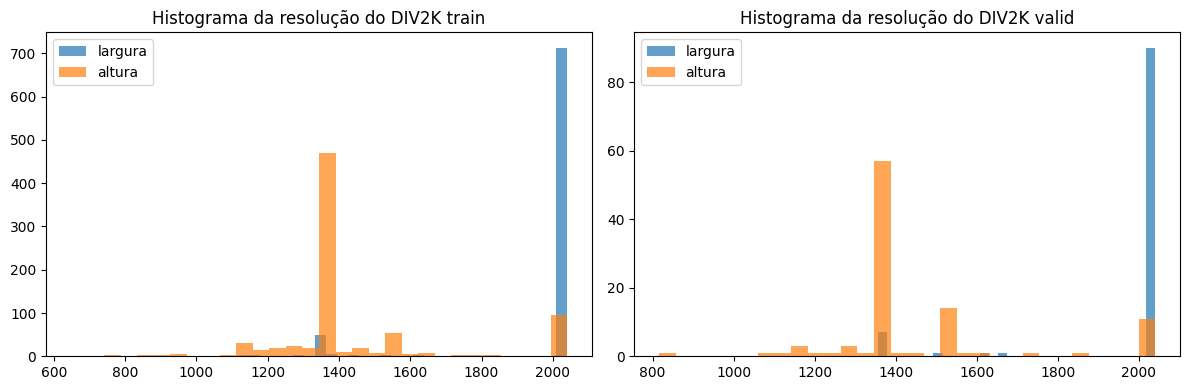

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_train["largura"], bins=30, alpha=0.7, label="largura")
axes[0].hist(df_train["altura"], bins=30, alpha=0.7, label="altura")
axes[0].set_title("Histograma da resolução do DIV2K train")
axes[0].legend()

axes[1].hist(df_valid["largura"], bins=30, alpha=0.7, label="largura")
axes[1].hist(df_valid["altura"], bins=30, alpha=0.7, label="altura")
axes[1].set_title("Histograma da resolução do DIV2K valid")
axes[1].legend()
plt.tight_layout()
plt.show()

Escrever algo aqui para confirmar qual tamanho de patch será adotado.
 
opções:     padroniza tudo em um único tamanho
            segue o tamanho de cada artigo

In [4]:
# verificação de segurança

patch_size = 200
menores = df_train[(df_train["largura"] < patch_size) | (df_train["altura"] < patch_size)]
print(f"{len(menores)} de {len(df_train)} imagens são menores que {patch_size}px em algum eixo")

0 de 800 imagens são menores que 200px em algum eixo


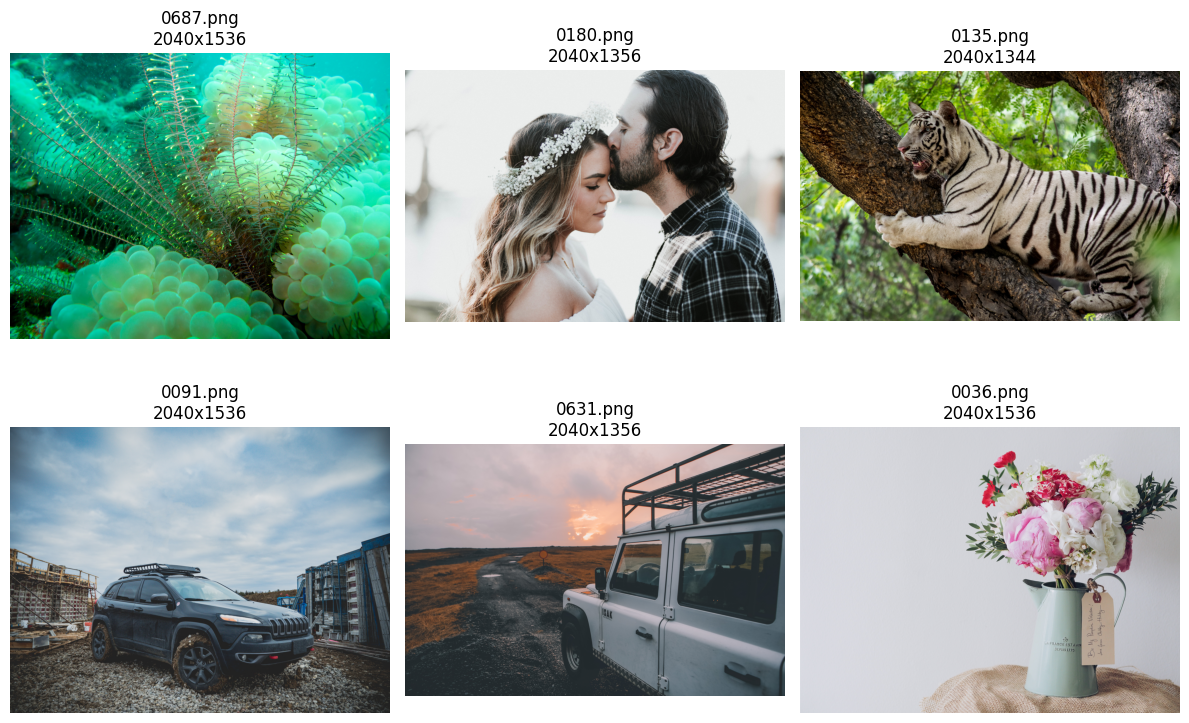

In [5]:
amostras = random.sample(list(Path("datasets/DIV2K_train_HR").glob("*.png")), 6)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, path in zip(axes.flat, amostras):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(f"{path.name}\n{img.size[0]}x{img.size[1]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

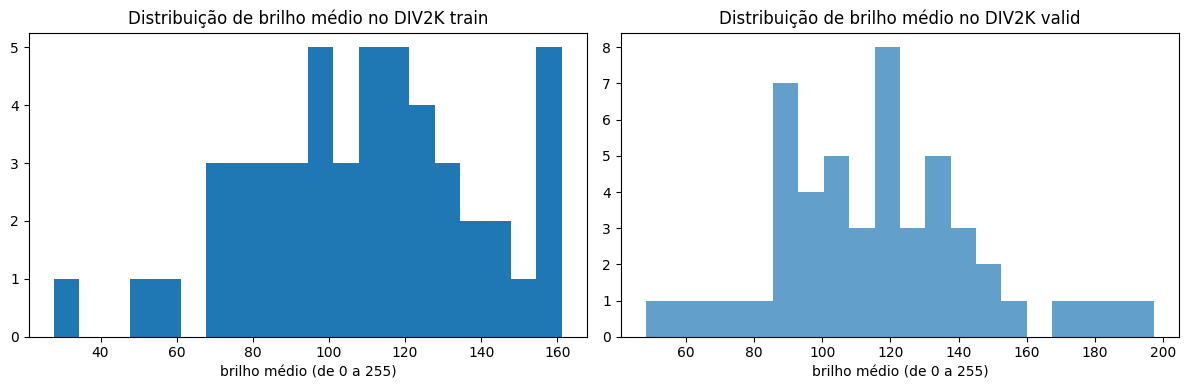

In [6]:
def brilho_medio(pasta, n=50):
    arquivos = random.sample(list(Path(pasta).glob("*.png")), n)
    valores = [np.array(Image.open(f).convert("L")).mean() for f in arquivos]
    return valores

brilho_train = brilho_medio("datasets/DIV2K_train_HR")
brilho_valid = brilho_medio("datasets/DIV2K_valid_HR")
fig , axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(brilho_train, bins=20, label="train")
axes[1].hist(brilho_valid, bins=20, alpha=0.7, label="valid")
axes[0].set_title("Distribuição de brilho médio no DIV2K train")
axes[1].set_title("Distribuição de brilho médio no DIV2K valid")
axes[0].set_xlabel("brilho médio (de 0 a 255)")
axes[1].set_xlabel("brilho médio (de 0 a 255)")
plt.tight_layout()
plt.show()

Transformações e Data Augmantation

falar sobre aqui

Falar sobre os patches

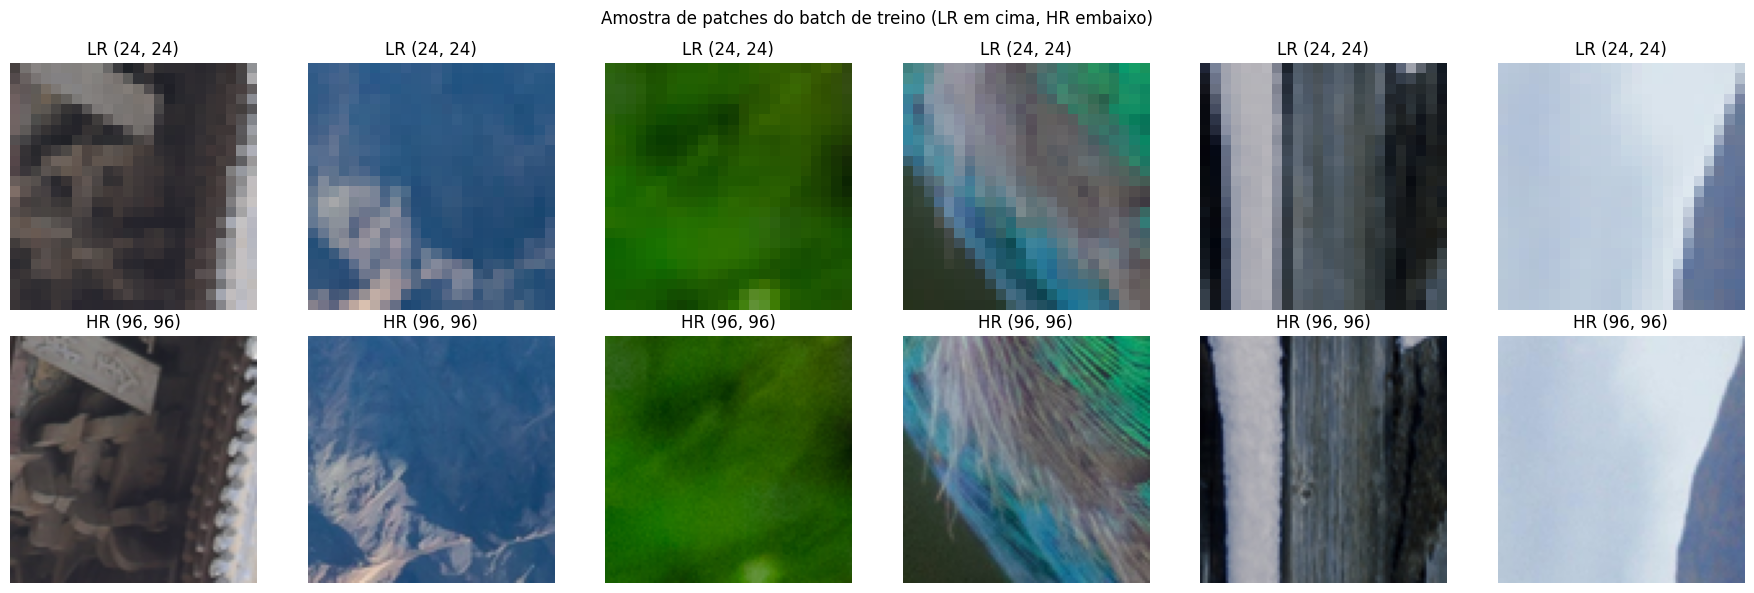

In [8]:
# definindo dataset de treino
train_dataset = SRDataset("datasets/DIV2K_train_HR", patch_size=96, scale=4)

sample_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)
lr_batch, hr_batch = next(iter(sample_loader))

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i in range(6):
    axes[0, i].imshow(lr_batch[i].permute(1, 2, 0))
    axes[0, i].set_title(f"LR {tuple(lr_batch[i].shape[1:])}")
    axes[0, i].axis("off")

    axes[1, i].imshow(hr_batch[i].permute(1, 2, 0))
    axes[1, i].set_title(f"HR {tuple(hr_batch[i].shape[1:])}")
    axes[1, i].axis("off")

plt.suptitle("Amostra de patches do batch de treino (LR em cima, HR embaixo)")
plt.tight_layout()
plt.show()

## Treinamento

Vamos implementar os modelos dos artigos. Inicialmente, vamos treinar o SRCNN:

In [9]:
# avaliação — precisa existir ANTES do loop, pois é usado dentro dele
eval_dataset = SRBenchmarkDataset("datasets/Set5/image_SRF_4", scale=4)
eval_loader = DataLoader(eval_dataset, batch_size=1, shuffle=False)

In [10]:
# treino
train_dataset = SRDataset("datasets/DIV2K_train_HR", patch_size=96, scale=4)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

model = SRCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

n_epochs = 100

srcnn_history = fit(model, train_loader, eval_loader, optimizer, criterion, device,
                     epochs=n_epochs, writer=writer, tag="srcnn")

Epoch 1/100 | Loss: 0.118460


KeyboardInterrupt: 

## Avaliação de resultados



In [ ]:
eval_dataset = SREvalDataset("datasets/DIV2K_valid_HR", scale=4)
eval_loader = DataLoader(eval_dataset, batch_size=1, shuffle=False)

model.eval()
psnr_list, ssim_list = [], []
psnr_bicubic_list = []

with torch.no_grad():
    for lr_img, hr_img in eval_loader:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        lr_up = F.interpolate(lr_img, scale_factor=4, mode="bicubic", align_corners=False)

        sr = model(lr_up).clamp(0, 1)

        psnr_list.append(calc_psnr(sr, hr_img))
        ssim_list.append(calc_ssim(sr, hr_img))
        psnr_bicubic_list.append(calc_psnr(lr_up, hr_img))

print(f"PSNR médio SRCNN:   {sum(psnr_list)/len(psnr_list):.2f} dB")
print(f"PSNR médio Bicubic: {sum(psnr_bicubic_list)/len(psnr_bicubic_list):.2f} dB")
print(f"SSIM médio SRCNN:   {sum(ssim_list)/len(ssim_list):.4f}")

In [ ]:
import matplotlib.pyplot as plt

def tensor_to_img(t):
    return t.detach().squeeze(0).permute(1, 2, 0).cpu().numpy().clip(0, 1)

model.eval()
n_samples = 5  # quantas imagens do conjunto de validação mostrar

fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))

with torch.no_grad():
    for i, (lr_img, hr_img) in enumerate(eval_loader):
        if i >= n_samples:
            break

        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        lr_up = F.interpolate(lr_img, scale_factor=4, mode="bicubic", align_corners=False)
        sr = model(lr_up).clamp(0, 1)

        psnr_bic = calc_psnr(lr_up, hr_img)
        psnr_sr = calc_psnr(sr, hr_img)

        axes[i, 0].imshow(tensor_to_img(hr_img))
        axes[i, 0].set_title("HR (original)")

        axes[i, 1].imshow(tensor_to_img(lr_up))
        axes[i, 1].set_title(f"Bicubic\nPSNR: {psnr_bic:.2f} dB")

        axes[i, 2].imshow(tensor_to_img(sr))
        axes[i, 2].set_title(f"SRCNN\nPSNR: {psnr_sr:.2f} dB")

        for ax in axes[i]:
            ax.axis("off")

plt.tight_layout()
plt.savefig(output_dir / "comparacao_geral.png", dpi=150)
plt.show()

In [ ]:
def crop_region(img_tensor, x, y, size=40):
    """Recorta uma região pequena de um tensor [1, C, H, W]"""
    return img_tensor[:, :, y:y+size, x:x+size]

# escolha manualmente uma imagem e coordenadas de uma região com textura
lr_img, hr_img = eval_dataset[0]
lr_img, hr_img = lr_img.unsqueeze(0).to(device), hr_img.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    lr_up = F.interpolate(lr_img, scale_factor=4, mode="bicubic", align_corners=False)
    sr = model(lr_up).clamp(0, 1)

# ajuste x, y conforme a região de interesse na imagem
x, y, size = 80, 60, 60

hr_crop = crop_region(hr_img, x, y, size)
bic_crop = crop_region(lr_up, x, y, size)
sr_crop = crop_region(sr, x, y, size)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(
    axes,
    [hr_crop, bic_crop, sr_crop],
    ["HR (original)", "Bicubic (zoom)", "SRCNN (zoom)"]
):
    ax.imshow(tensor_to_img(img))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig(output_dir / "zoom_detalhe.png", dpi=150)
plt.show()

In [ ]:
diff_bicubic = (lr_up - hr_img).abs().mean(dim=1, keepdim=True)
diff_srcnn = (sr - hr_img).abs().mean(dim=1, keepdim=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(diff_bicubic.squeeze().cpu(), cmap="hot")
axes[0].set_title("Erro absoluto — Bicubic")
axes[1].imshow(diff_srcnn.squeeze().cpu(), cmap="hot")
axes[1].set_title("Erro absoluto — SRCNN")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.savefig(output_dir / "mapa_erro.png", dpi=150)
plt.show()

## EDSR-Baseline

Agora vamos treinar o EDSR-baseline (16 blocos residuais, 64 filtros, sem BatchNorm) e comparar com SRCNN.

In [ ]:
# Recarregar módulos (importante após editar .py files)
import importlib
import sys
if 'models' in sys.modules:
    importlib.reload(sys.modules['models'])

from models import EDSRBaseline

# Treino EDSR-baseline
train_dataset_edsr = SRDataset("datasets/DIV2K_train_HR", patch_size=96, scale=4)
train_loader_edsr = DataLoader(train_dataset_edsr, batch_size=16, shuffle=True)

edsr_model = EDSRBaseline(num_features=64, num_blocks=16, scale=4).to(device)
edsr_optimizer = torch.optim.Adam(edsr_model.parameters(), lr=1e-4)
edsr_criterion = nn.L1Loss()

n_epochs_edsr = 100

print("Iniciando treino do EDSR-baseline...")
for epoch in range(n_epochs_edsr):
    loss = train_one_epoch(edsr_model, train_loader_edsr, edsr_optimizer, edsr_criterion, device, upscale_input=False)
    writer.add_scalar("Loss/train_edsr", loss, epoch)

    if (epoch + 1) % 5 == 0:
        result = evaluate(edsr_model, eval_loader, device, upscale_input=False)
        writer.add_scalar("PSNR/val_edsr", result["psnr_model"], epoch)
        writer.add_scalar("SSIM/val_edsr", result["ssim_model"], epoch)

    print(f"Epoch {epoch+1}/{n_epochs_edsr} — loss: {loss:.6f}")

writer.close()
print("\nTreinamento do EDSR concluído!")
print(evaluate(edsr_model, eval_loader, device, upscale_input=False))

## Comparação em Benchmarks Padrão

Agora vamos avaliar ambos os modelos nos benchmarks oficiais (Set5, Set14, BSD100, Urban100).

In [ ]:
import pandas as pd

# Carregar todos os benchmarks
benchmarks = {
    "Set5": SRBenchmarkDataset("datasets/Set5/image_SRF_4", scale=4),
    "Set14": SRBenchmarkDataset("datasets/Set14/image_SRF_4", scale=4),
    "BSD100": SRBenchmarkDataset("datasets/BSD100/image_SRF_4", scale=4),
    "Urban100": SRBenchmarkDataset("datasets/Urban100/image_SRF_4", scale=4),
}

benchmark_loaders = {
    name: DataLoader(ds, batch_size=1, shuffle=False)
    for name, ds in benchmarks.items()
}

# Avaliar SRCNN e EDSR em todos os benchmarks
results_table = []

print("Avaliando SRCNN e EDSR-baseline nos benchmarks...")
print("=" * 80)

for benchmark_name, loader in benchmark_loaders.items():
    print(f"\n{benchmark_name}:")
    
    # SRCNN
    srcnn_metrics = evaluate(model, loader, device, upscale_input=True)
    print(f"  SRCNN  | PSNR: {srcnn_metrics['psnr_model']:.2f} dB | SSIM: {srcnn_metrics['ssim_model']:.4f}")
    
    # EDSR
    edsr_metrics = evaluate(edsr_model, loader, device, upscale_input=False)
    print(f"  EDSR   | PSNR: {edsr_metrics['psnr_model']:.2f} dB | SSIM: {edsr_metrics['ssim_model']:.4f}")
    
    # Bicubic baseline
    print(f"  Bicubic| PSNR: {srcnn_metrics['psnr_bicubic']:.2f} dB")
    
    psnr_diff = edsr_metrics['psnr_model'] - srcnn_metrics['psnr_model']
    ssim_diff = edsr_metrics['ssim_model'] - srcnn_metrics['ssim_model']
    winner = "EDSR ✓" if psnr_diff > 0 else "SRCNN ✓"
    print(f"  Diferença: PSNR {psnr_diff:+.2f} dB | SSIM {ssim_diff:+.4f} | {winner}")
    
    results_table.append({
        "Dataset": benchmark_name,
        "SRCNN PSNR": f"{srcnn_metrics['psnr_model']:.2f}",
        "EDSR PSNR": f"{edsr_metrics['psnr_model']:.2f}",
        "SRCNN SSIM": f"{srcnn_metrics['ssim_model']:.4f}",
        "EDSR SSIM": f"{edsr_metrics['ssim_model']:.4f}",
        "Bicubic PSNR": f"{srcnn_metrics['psnr_bicubic']:.2f}",
    })

# Criar tabela
df_results = pd.DataFrame(results_table)
print("\n" + "=" * 80)
print("TABELA COMPARATIVA")
print("=" * 80)
print(df_results.to_string(index=False))

# Salvar tabela
df_results.to_csv(output_dir / "results_comparison.csv", index=False)
print(f"\nTabela salva em: {output_dir / 'results_comparison.csv'}")

## Visualização Comparativa: SRCNN vs EDSR

Vamos visualizar lado a lado: HR original, Bicubic, SRCNN e EDSR em alguns benchmarks.

In [ ]:
# Visualizar comparação em Set5 e Set14
def visualize_comparison(dataset, loader, model_srcnn, model_edsr, title, n_samples=3):
    fig, axes = plt.subplots(n_samples, 4, figsize=(14, 4 * n_samples))
    
    model_srcnn.eval()
    model_edsr.eval()
    
    with torch.no_grad():
        for i, (lr_img, hr_img) in enumerate(loader):
            if i >= n_samples:
                break
            
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)
            
            # SRCNN (com bicubic prévio)
            lr_up = F.interpolate(lr_img, scale_factor=4, mode="bicubic", align_corners=False)
            sr_srcnn = model_srcnn(lr_up).clamp(0, 1)
            
            # EDSR (upsampling interno)
            sr_edsr = model_edsr(lr_img).clamp(0, 1)
            
            psnr_bicubic = calc_psnr(lr_up, hr_img)
            psnr_srcnn = calc_psnr(sr_srcnn, hr_img)
            psnr_edsr = calc_psnr(sr_edsr, hr_img)
            
            axes[i, 0].imshow(tensor_to_img(hr_img))
            axes[i, 0].set_title("HR Original")
            
            axes[i, 1].imshow(tensor_to_img(lr_up))
            axes[i, 1].set_title(f"Bicubic\nPSNR: {psnr_bicubic:.2f} dB")
            
            axes[i, 2].imshow(tensor_to_img(sr_srcnn))
            axes[i, 2].set_title(f"SRCNN\nPSNR: {psnr_srcnn:.2f} dB")
            
            axes[i, 3].imshow(tensor_to_img(sr_edsr))
            axes[i, 3].set_title(f"EDSR\nPSNR: {psnr_edsr:.2f} dB")
            
            for ax in axes[i]:
                ax.axis("off")
    
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    return fig

# Visualizar Set5
fig_set5 = visualize_comparison(
    benchmarks["Set5"], benchmark_loaders["Set5"], 
    model, edsr_model, "Comparação em Set5 (3 amostras)"
)
plt.savefig(output_dir / "comparacao_set5.png", dpi=150, bbox_inches="tight")
plt.show()

# Visualizar Set14
fig_set14 = visualize_comparison(
    benchmarks["Set14"], benchmark_loaders["Set14"], 
    model, edsr_model, "Comparação em Set14 (3 amostras)", n_samples=3
)
plt.savefig(output_dir / "comparacao_set14.png", dpi=150, bbox_inches="tight")
plt.show()

## Salvar Modelos e Resumo Final

In [ ]:
# Salvar modelos treinados
torch.save(model.state_dict(), output_dir / "srcnn_final.pt")
torch.save(edsr_model.state_dict(), output_dir / "edsr_final.pt")

print("✅ Modelos salvos:")
print(f"  - {output_dir / 'srcnn_final.pt'}")
print(f"  - {output_dir / 'edsr_final.pt'}")

# Criar um resumo dos resultados em JSON
import json

summary = {
    "project": "Super-Resolução de Imagens (ML2 2026)",
    "students": ["Marcos Abílio", "Gabriel Vieira"],
    "models": ["SRCNN (Dong et al., 2016)", "EDSR-baseline (Lim et al., 2017)"],
    "training": {
        "scale": 4,
        "epochs": n_epochs,
        "batch_size": 16,
        "patch_size": 96,
        "learning_rate": 1e-4,
        "train_set": "DIV2K (800+ imagens)",
        "device": str(device),
    },
    "results": results_table,
}

with open(output_dir / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n✅ Resumo salvo em: {output_dir / 'summary.json'}")
print("\n" + "="*80)
print("EXPERIMENTO CONCLUÍDO!")
print("="*80)
print(f"Todos os resultados foram salvos em: {output_dir}")
print("\nArquivos gerados:")
print("  - srcnn_final.pt (modelo SRCNN)")
print("  - edsr_final.pt (modelo EDSR)")
print("  - results_comparison.csv (tabela de resultados)")
print("  - summary.json (resumo do experimento)")
print("  - comparacao_set5.png / comparacao_set14.png (visualizações)")
print("  - tensorboard/ (logs de treinamento)")